# File Operations and Regular Expressions 

**🎯 Lesson Objectives**

**By the end of this lesson, you will be able to:**

- **Manage Files and Directories** using Python's **os** and **shutil** modules.  
- **Read and Write Text Files** with **open()** and **with open()**.  
- **Extract Text from Word and PDF Files** using **docx2txt** and **pdfplumber**.  
- **Use Regular Expressions** to search, match, and replace text.  
- **Apply Regex for Data Cleaning and Extraction**.  

 

**🎯What we will cover:**

**Part 1: File Operations**

- **Manage Files and Directories**  
  - Create, copy, move, rename, and delete files using **os** and **shutil**.  
  - List files in directories using **glob**.  
  
- **Read and Write Text Files**  
  - Open, read, and modify files using **open()** with different modes.  
  - Use **with open()** to handle files safely and efficiently.  
  - Read and write file content using **read(), readlines(), and write()**.  
  
- **Extract Text from Word and PDF Files**  
  - Use **docx2txt** to extract text from Word documents.  
  - Extract content from PDFs using **pdfplumber**.  
  - Process and manipulate extracted text in Python.  
  
**Part 2: Regular Expressions**

- **Use Regular Expressions for Pattern Matching**  
  - Search for specific text patterns using **re.match()** and **re.search()**.  
  - Extract multiple occurrences with **re.findall()**.  
  - Replace text using **re.sub()**.  
  
- **Apply Regex for Data Cleaning and Extraction**  
  - Validate input formats (e.g., email addresses, phone numbers).  
  - Extract relevant information from text-based documents.  
  - Use grouping with **re.group()** to capture specific parts of matches.  
  
- **Practice and Test Regular Expressions**  
  - Use online tools to test regex patterns.  
  - Apply regex techniques in real-world data processing tasks.  


# 🚀 Part 1:  File Operations

## ☑️ Working with Files and Directories

There are several modules in the Python Standard Library which can help us **create**, **copy**, **move**, **rename**, and **remove** files and directories:

### 🔹 Working with the `os` Module

In [1]:
# Inspect files in data folder
import os

os.listdir('data')

['wrong_name.txt',
 'poem.txt',
 'useless_file.txt',
 'standard_operating_procedure.docx',
 'product_list.pdf',
 'air_quality.docx',
 'account_numbers.txt',
 'research.pdf',
 'summary_email.txt',
 'jack_email.txt',
 'corrected_account_numbers.txt']

In [2]:
# Clean up and organise the data folder:
# - Remove an unnecessary file ('useless_file.txt')
# - Rename 'wrong_name.txt' to 'right_name.txt' for clarity
# - Create a 'backups' directory to store backup files

os.remove('data/useless_file.txt')
os.rename('data/wrong_name.txt', 'data/right_name.txt')
os.mkdir('data/backups')

- Here we used the `os` module to `.remove()` and `.rename()` some files
- We created a new directory using `.mkdir()` *'make directory'*

### 🔹 Using the `shutil` Module

In [3]:
import shutil

# Copy 'right_name.txt' to create a duplicate named 'right_name_copy.txt'
shutil.copy('data/right_name.txt', 'data/right_name_copy.txt')

# Move the copied file into the 'backups' directory for safekeeping
shutil.move('data/right_name_copy.txt', 'data/backups/right_name_copy.txt')

'data/backups/right_name_copy.txt'

- As with `os`, the `shutil` module methods requiring two arguments are provided in the order `(source, destination)`

The methods shown here from `os` and `shutil` with throw **errors** if certain conditions are met:
- `.copy()`, `.move()`, `.remove()` and `.rename()` operations if the **source** file or directory **does not exist** 
- `.mkdir()` operations if the **destination** directory **already exists**

... although note that `shutil.move()` when used with a file will **overwrite** an existing file at the destination.

### 🔹 Listing Files Using the `glob` Module

In [4]:
from glob import glob

files = glob('data/*.txt')
files

['data/poem.txt',
 'data/right_name.txt',
 'data/account_numbers.txt',
 'data/summary_email.txt',
 'data/jack_email.txt',
 'data/corrected_account_numbers.txt']

- We have created a list of all `.txt` files in the `data` directory

## ☑️ Working with Text Files

Python comes with the **built-in function** `open()`, which can be used to **open**, **read**, **modify** and **save** files. 

- We are likely to use other packages such as `pandas` when using tabular data file formats such as `.csv` and `.xlsx`  
... but `open()` can be useful for performing operations on **text files** such as `.txt` and `.rtf` files

### 🔹 Using the `open()` function

```python
open(file, mode='r', buffering=-1, encoding=None, errors=None, 
     newline=None, closefd=True, opener=None)
```     

The main parameters of the function are:

- `file`: this is the only required parameter and the argument provided for it should be the **path to the file** to be worked with (or the path where it is to be created)
- `mode`: this tells Python **what to do** with the given file or file location

The following table from the [documentation](https://docs.python.org/3/library/functions.html#open) shows what values can be used with `mode` parameter:

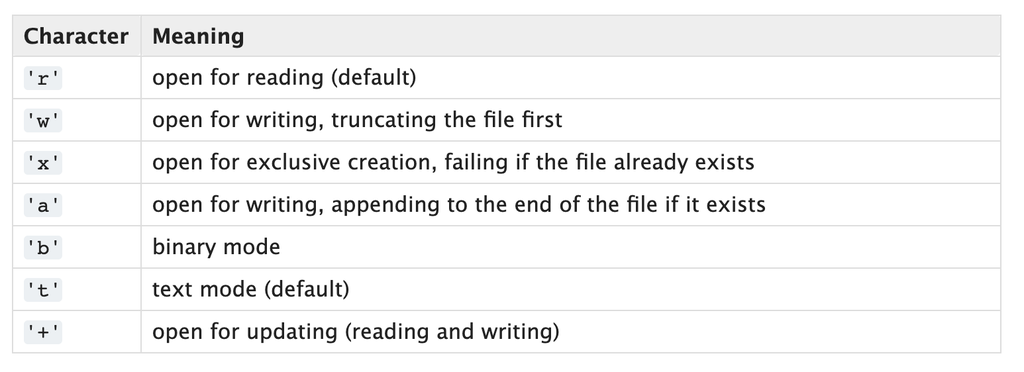

- It is possible to provide more than one of these characters at the same time, for example `'r+'`

In [5]:
# This opens the file in read-only mode. You can read from it, but not write to it.

email = open('data/summary_email.txt', 'r')
email

<_io.TextIOWrapper name='data/summary_email.txt' mode='r' encoding='UTF-8'>

`open()` returns an object of type `_io.TextIOWrapper`, which has a number of methods, including:

- `.read()`: returns a string of the characters in the file
- `.write()`: allows a string to be written to the file
- `.close()`: closes the file (meaning it cannot be read or written to)

### 🔹 Reading files

In [6]:
# display the full content
email.read()

'Hi John,\n\nThis week our profit was £52.75.\n\nKind Regards,\nDave'

- the `.read()` method returns a string of the characters in our `.txt` file
- `\n` represents a **newline** - so two in a row means there is a blank line

### 🔹 Position in the file

By calling the `.read()` method, Python has moved through the file reading each character.

In doing so it has moved what can be considered a **file pointer** from the start to the end of the file.

If we call `.read()` again, an empty string is returned:

In [7]:
email.read()

''

In [8]:
email.seek(0)
email.read()

'Hi John,\n\nThis week our profit was £52.75.\n\nKind Regards,\nDave'

- The `.seek()` method allows us to move the pointer to a **position** in the string of our choice

We could instead use `open()` and `.read()` together every time we want to read the file:

In [9]:
text = open('data/summary_email.txt', 'r').read()
text

'Hi John,\n\nThis week our profit was £52.75.\n\nKind Regards,\nDave'

- The pointer will start at position `0` upon using `open()` to `.read()` the file again

#### 💡 Knowledge Check 1

Which of the following are valid modes for the `open()` function? 

*Select all that apply*

- **A)** 'r' - read
- **B)** 'p' - print
- **C)** 'q' - query
- **D)** 'w' - write

In [10]:
#put your answer below


### 🔹 Using the `with` function

Although more important in systems with **concurrent processes** working with files, it is good practice to **close files** when they are no longer being used.

The `with` function can be used to **automatically open and close files** before and after the required operation(s) are made:

In [11]:
with open('data/summary_email.txt', 'r') as email:    
    text = email.read()

text

'Hi John,\n\nThis week our profit was £52.75.\n\nKind Regards,\nDave'

In [12]:
with open('data/summary_email.txt', 'r') as email:    
    lines = email.readlines()

lines

['Hi John,\n',
 '\n',
 'This week our profit was £52.75.\n',
 '\n',
 'Kind Regards,\n',
 'Dave']

- The `.readlines()` method returns a list where each element contains one line of the text file

We can now work with the returned `list` object as usual, for example using list and string **indexing** to extract part of the message:

In [13]:
lines[0]

'Hi John,\n'

In [14]:
greeting = lines[0]
space_index = greeting.index(' ')                # Finds the space after 'Hi'
comma_index = greeting.index(',')                # Finds the comma after 'John'
name = greeting[space_index + 1 : comma_index]   # Extracts 'John'
name

'John'

An alternative approach to achieve this is to use the `.splitlines()` string method on the string returned by `.read()`:

In [15]:
text.splitlines()[0:3]

['Hi John,', '', 'This week our profit was £52.75.']

The `.splitlines()` method has removed the newline `\n` character sequences:
- a tidier result which may help us with subsequent operations to retrieve information  
... but means that more code would be required to re-instate the newlines if we were to modify the file and save it

### 🔹 Updating file contents

For the purposes of our example we can continue to work with the `lines` list object, and the first element of that list which we assigned to `greeting`:

In [16]:
new_name = 'Jack'
new_greeting = greeting[0 : space_index + 1] + new_name + ','
new_greeting

'Hi Jack,'

In [17]:
new_message = lines.copy()
new_message[0] = new_greeting
new_text = ''
for line in new_message:
    new_text += line
new_text

'Hi Jack,\nThis week our profit was £52.75.\n\nKind Regards,\nDave'

- the `.copy()` method is used so that we can work on `new_message` without affecting `lines`
- the first element of that list (i.e. the first line of the message) is updated to `new_greeting`
- to create a string ready to be written to a file, we add each element to the `new_text` string

### 🔹 Writing files

In [18]:
with open('data/jack_email.txt', 'w') as file:
    file.write(new_text)

- we use `'w'` as the argument for the `mode` parameter of the `open()` function
- the `.write()` method of the object returned by `open()` allows us to specify a string to be written to that file

*Note that there is no warning or confirmation required; the file will be overwritten completely with the contents on the provided string.* 

#### 💡 Knowledge Check 2

Why is it recommended to use the with **statement** when working with `open()` in Python?

- **A)** It allows reading and writing files without specifying a file path.
- **B)** It prevents all file modification operations.
- **C)** Itt allows multiple files to be opened at the same time.
- **D)** It automatically closes the file after you're done.

In [19]:
#put your answer below


---




## ☑️ Extracting text from Word documents and PDFs 

`.docx` and `.pdf` file formats cannot be worked with as previously shown for `.txt` files.

- The format in which they are **encoded** (and **decoded**) differs
- Attibutes such as **formatting** and **images** also need to be stored


The following **packages** were created to help such operations:
- `docx2txt` [[documentation](https://github.com/ankushshah89/python-docx2txt)]
- `pdfplumber` [[documentation](https://github.com/jsvine/pdfplumber)]

These can be installed by uncommenting and running the following code:

In [20]:
#!pip install docx2txt

In [21]:
#!pip install pdfplumber

### 🔹 Word documents

In [22]:
import docx2txt

doc_text = docx2txt.process('data/standard_operating_procedure.docx')
print(doc_text)

SITE FILE MANAGEMENT





STANDARD OPERATING PROCEDURE NO 

SOP 08

DATE RATIFIED 

Sep 2014

NEXT REVIEW DATE 

Sep 2016











POLICY STATEMENT/KEY OBJECTIVES:

To describe the procedure for the maintenance of essential documents and investigator site file at a research study site.





POLICY AUTHOR: Katie Glickman; Research Facilitator








BACKGROUND

With the large volume of documentation required for each clinical trial, a standard filing system is necessary.  From receipt of a research proposal / outline protocol, documentation for each study should be kept in a specific study file with a dedicated member of staff responsible for maintaining and updating the file.



Some sponsors may provide the Investigator Site File for specific studies, however, non-commercial studies often do not.



The International Conference of Harmonisation, Good Clinical Practice (ICH-GCP) guidelines define the study documents to be filed as essential documents “those documents which individua

Having extracted the text to a Python string, we can then work with Python as usual:

In [23]:
lines = doc_text.split('\n')
rat_date_index = lines.index('DATE RATIFIED ') + 2
rat_date = lines[rat_date_index]
rat_date

'Sep 2014'

- we used the `.split()` method with an argument of `\n` to split the string into a list where each element was one line of text from the original file
- we used `.index()` to locate a specific line and (from prior knowledge) knew that the information of interest would be found two lines later

### 🔹 PDFs

In [24]:
import pdfplumber

pdf = pdfplumber.open('data/product_list.pdf')
front_page = pdf.pages[0]      #Retrieves the first page of the PDF (index 0)

The `.open()` method creates an object with the following properties:
- `.pages`: a list of objects representing each page in the PDF
- `.metadata`: details about the file such as creation date and author

In [25]:
# printing the text content extracted from the first page (index 0) of the PDF file

print(front_page.extract_text())

Cannot set gray non-stroke color because /'P0' is an invalid float value


Product List 2019
Finished Dosage Forms (Partner Label),
Active Pharmaceutical Ingredients
B2B


- each `Page` object has an `.extract_text()` method, which returns a string for us to work with

#### 💡 Knowledge Check 3

What process could we use to iterate through the pages of a `pdf`?

*Using the code pictured as a hint*

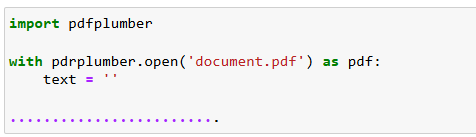

In [26]:
#put your answer below


---

# 🚀 Part 2: Regular Expressions

**Regular expressions** (also known as '**regex**') allow us to **search strings** for text which matches a specified **pattern**.  
  
Examples of where regular expressions are useful:  
  
- Form or program **input validation**
- **Extracting data** from documents
- **Finding** and **replacing** text 
- Bulk **renaming** of files
- Calculating **word frequency**

### 🔹 Regex in Python
 
The `re` module can be used for regular expressions in Python.  
  
The syntax for finding patterns in text has some special **metacharacters**, which are intepreted in particular ways to simplify common pattern matching operations:

```
. ^ $ * + ? { } [ ] \ | ( )

```

**Here are some examples of the uses of these metacharacters; the string on the left is used to find instances of the pattern given on the right:**

    \d      Any Digit
    \D      Any Non-digit character
    .       Any Character
    \.      Period
    [abc]   Only a, b, or c
    [^abc]  Not a, b, nor c
    [a-z]   Characters a to z
    [0-9]   Numbers 0 to 9
    \w      Any Alphanumeric character
    \W      Any Non-alphanumeric character
    *       Zero or more repetitions
    +       One or more repetitions
    ?       Optional character
    \s      Any Whitespace
    \S      Any Non-whitespace character

### 🔹 Using `re` and raw strings

In the same way as `f` can be added before a string to allow formatting of that string, we can use `r` to designate the following string as a **raw string**.  

In a raw string, the usual **escape character** `\` is treated as a normal character, i.e. it will not result in any special behaviour and simply be part of the string. 

In [27]:
import re

text = 'Winners for season 2019/20: \nLiverpool'

- Using a rew string will allow us to locate the `\n` in `text` later on

### 🔹 Using `.match()`

In [28]:
import re
text = 'Winners for season 2019/20: \nLiverpool'

winner_text = re.match('Winners for season.+', text)   #matches lines that start with "Winners for season"

if winner_text:
    print(winner_text.string)

Winners for season 2019/20: 
Liverpool


- the `.match()` method allows us to determine whether the **start** of a string matches the provided **pattern**
- `.match()` will return `None` if this is not the case, otherwise a `Match` object
- the `.string` attribute of a `Match` object returns the original string

### 🔹 Using `.search()`

In [29]:
import re
text = 'Winners for season 2019/20: \nLiverpool'

pattern = r'\n' #A raw string pattern that matches a newline character.

find_newline = re.search(pattern, text)
find_newline

<re.Match object; span=(28, 29), match='\n'>

- we used the `.search()` method to find the **position** of `pattern` within `text`
- the returned `Match` object is not immediately useful, but has numerous associated methods which are 

In [30]:
champions = text[find_newline.end() : ]
champions

'Liverpool'

- the `.end()` method gives us the **index** of the character following the matched regex
    - we can use this with list indexing to extract part of `text` which is of interest

### 🔹 Using `.findall()`

In [31]:
import re
text = 'Winners for season 2019/20: \nLiverpool'

season = re.findall(r'\d+/\d+', text)
season[0]

'2019/20'

In [32]:
# Pattern Breakdown:
# \d+ → Matches one or more digits
# / → Matches the forward slash literally
# \d+ → Again, matches one or more digits

- we used the regex sequence `\d` to match any digit several times, with a `/` in the middle
- the `findall()` method returns a list of matching **substrings**, from which we accessed the first (and in this case only) element

#### 💡 Knowledge Check 4

What is the primary difference between `.match()` and `.search()` in Python's re module?

- **A)** `.match()` looks for a pattern only at the beginning of the string, while `.search()` looks for a pattern anywhere in the string.
- **B)** `.search()` returns a list of all matches, whereas `.match()` only returns the first match.
- **C)** `.match()` can be used with the `.findall()` method, but `.search()` cannot.
- **D)** `.search()` modifies the original string, whereas `.match()` does not.

In [33]:
#put your answer below


---


### 🔹 Using `.sub()`

In [34]:
import re
text = 'Winners for season 2019/20: \nLiverpool'

new_entry = re.sub('Liverpool', 'SEASON VOID', text)
print(new_entry)

Winners for season 2019/20: 
SEASON VOID


- the `.sub()` method allows us to **substitute** one substring for another

### 🔹 Using `.group()`

In [35]:
entry = 'elizabeth.windsor@thepalace.co.uk'
royal = re.match(r'[\w]*\.[\w]*@thepalace\.co\.uk', entry)
royal.group()

'elizabeth.windsor@thepalace.co.uk'

In [36]:
# Pattern Breakdown:
# [\w]* - Matches zero or more word characters (letters, digits, underscore)
# \. - Matches a literal dot (.)
# [\w]* - Matches zero or more word characters again
# @thepalace\.co\.uk - Matches the exact domain @thepalace.co.uk

- here the `.group()` method of the `Match` object returns the whole string, as we have not specified any groups in our regular expression

`.group()` can also be used in conjunction with `(`parentheses`)` in the regex pattern to access **specific parts** of a match:

In [37]:
import re

entry = 'elizabeth.windsor@thepalace.co.uk'
royal_names = re.match(r'([\w]*)\.([\w]*)@thepalace\.co\.uk', entry)

first_name = royal_names.group(1).capitalize()
surname = royal_names.group(2).capitalize()

print(royal_names.group(0))
print(f'HRH {first_name} {surname}')

elizabeth.windsor@thepalace.co.uk
HRH Elizabeth Windsor


In [38]:
# Pattern Breakdown with Groups:
# ([\w]*) → Group 1: Matches zero or more word characters (first part of the name, e.g. elizabeth)
# \. → Literal dot (.)
# ([\w]*) → Group 2: Matches zero or more word characters (second part, e.g. windsor)

Notice that the number passed to `.group()` is not an index; `.group(0)` returns the full matching string and `1` and `2` return the first and second parts, each designated by `(`parentheses`)` in the regular expression.

#### 💡 Knowledge Check 5

Anonymise the following **phone number**. Replace **all** of the digits with `#`. What arguments can we use in place of ...?


*Use "". Your answer should look like - r"..."*

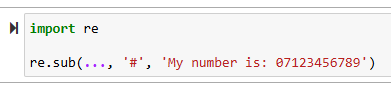

In [39]:
#put your answer below


### 🔹 Testing and practicing regex

There are several tools online, such as [pythex](https://pythex.org/), where you can test that your regular expressions work as expected on a given string.

### **🔑 Summary / Key Takeaways**
By completing this lesson, you should now be able to:


- ✅ **Manage files and directories** using `os`, `shutil`, and `glob`.  
- ✅ **Read and write text files** safely with `open()`, `with open()`, and file methods.  
- ✅ **Extract text from documents** using `docx2txt` for Word files and `pdfplumber` for PDFs.  
- ✅ **Find and manipulate text with regex** using `re.match()`, `re.search()`, `re.findall()`, and `re.sub()`.  
- ✅ **Apply regex for data cleaning**, including validating emails and phone numbers.  
- ✅ **Practice and test regex** using online tools and real-world datasets.  


### **📝 Next Steps:**  

- **Complete the practical lab work**: Open and work through the following workbook:`file-operations-regex-workbook.ipynb`. 